# Session 7 — Spike classification (Stage 1)

**Task.** Predict whether each hour of ERCOT day-ahead pricing at HB_HOUSTON exceeds the $100/MWh spike threshold chosen in notebook 01. Binary classification, 5-fold expanding-window time-series CV, 16 features (9 weather + 1 fuel + 6 calendar).

This notebook walks through the modeling work from Session 7 (now also called **Stage 1** because the final-submission pipeline composes Stage 1 with a Stage 2 magnitude regressor — see `multihub_findings.md` and `notebooks/08_combined_evaluation.ipynb`).

**Training scripts (source of truth for the code):**
- `src/build_features.py` — produces `data/processed/modeling_data.parquet`
- `src/train_logistic.py` — six-variant logistic grid
- `src/train_random_forest.py` — nine-variant RF grid
- `src/train_knn.py` — k ∈ {5, 25, 75, 200}
- `src/recency_analysis.py` — three training windows
- `src/compare_models.py` — cross-class comparison plots

This notebook loads the saved JSON / npz / pkl artifacts those scripts produced so it can be re-executed in a few seconds instead of re-running the full grid. To regenerate the underlying artifacts, run the scripts above.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from joblib import load
from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score

PROJECT_ROOT = Path('/Users/raetng/Documents/UChicago/ADA/priv_project_raetng')
DATA_PATH    = PROJECT_ROOT / 'data' / 'processed' / 'modeling_data.parquet'
SESSION_DIR  = PROJECT_ROOT / 'outputs' / 'session7'
MODELS_DIR   = PROJECT_ROOT / 'models'

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. The modeling matrix

`src/build_features.py` filters the merged dataset to HB_HOUSTON, applies the $100/MWh spike threshold to define the binary target, and keeps the 16-feature predictor set whose relevance was established in notebook 03 (weather + gas) plus the calendar features added during the merge.

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f'Shape:       {df.shape}')
print(f'Date range:  {df["datetime"].min()} -> {df["datetime"].max()}')
print(f'Spike count: {int(df["is_spike"].sum()):,}  ({df["is_spike"].mean()*100:.2f}%)')

feature_cols = [c for c in df.columns if c not in ('datetime', 'is_spike')]
print(f'\n{len(feature_cols)} features:')
print('  weather:  ', [c for c in feature_cols if c not in ('gas_price_henry_hub', 'hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'is_holiday')])
print('  fuel:     ', ['gas_price_henry_hub'])
print('  calendar: ', ['hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'is_holiday'])

Shape:       (63791, 18)
Date range:  2019-01-01 00:00:00 -> 2026-04-11 23:00:00
Spike count: 2,845  (4.46%)

16 features:
  weather:   ['temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'dewpoint_2m', 'cloud_cover', 'wind_speed_10m', 'wind_speed_100m', 'shortwave_radiation', 'direct_normal_irradiance']
  fuel:      ['gas_price_henry_hub']
  calendar:  ['hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'is_holiday']


### Spike rate over time

The yearly spike rate varies dramatically — 2022 was a high-volatility year (post-Uri scarcity + summer heat + Russia-driven gas), 2024 was much calmer. This non-stationarity is the main reason every model below has large fold-to-fold variance and is why we revisit it explicitly with a recency analysis at the end.

       sum  count    rate
year                     
2019   228   8760  0.0260
2020    68   8784  0.0077
2021   375   8760  0.0428
2022  1223   8760  0.1396
2023   566   8760  0.0646
2024   165   8784  0.0188
2025   131   8760  0.0150
2026    89   2423  0.0367


<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
/var/folders/65/r790x4c94lqctyfknd7pnq_r0000gn/T/ipykernel_60153/2712731123.py:11: SyntaxWarning: invalid escape sequence '\$'
  ax.set_title('Annual spike rate at HB_HOUSTON  (spikes = SPP > \$100/MWh)')


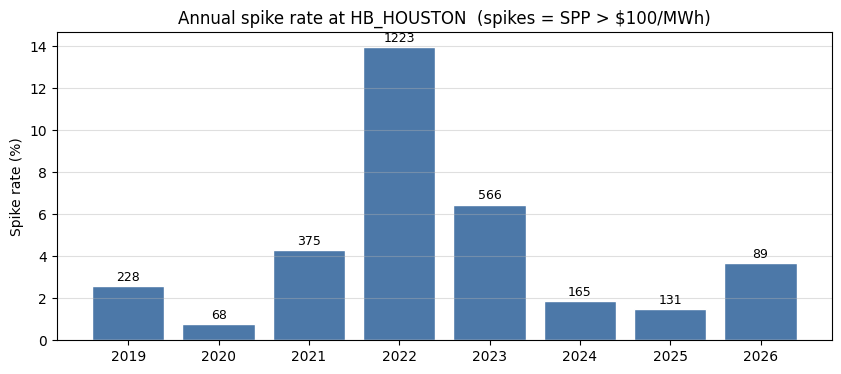

In [3]:
df['year'] = df['datetime'].dt.year
spike_by_year = df.groupby('year')['is_spike'].agg(['sum', 'count'])
spike_by_year['rate'] = spike_by_year['sum'] / spike_by_year['count']
print(spike_by_year.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(spike_by_year.index.astype(str), spike_by_year['rate'] * 100, color='#4c78a8', edgecolor='white')
for x, (_, row) in zip(spike_by_year.index.astype(str), spike_by_year.iterrows()):
    ax.text(x, row['rate']*100 + 0.1, f"{int(row['sum'])}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Spike rate (%)')
ax.set_title('Annual spike rate at HB_HOUSTON  (spikes = SPP > \$100/MWh)')
ax.grid(True, alpha=0.4, axis='y')
plt.show()

## 2. Evaluation framework

The positive class is rare (4.46% overall), so we **chose PR-AUC (average precision) as the headline metric *before training any models***. ROC-AUC is optimistic on imbalanced data because most of the ROC space is dominated by easy true-negatives; PR-AUC reflects how well a model ranks the actual spikes near the top of its predicted-probability list — which is what an operations user actually cares about.

Secondary metrics: ROC-AUC (sanity check on ranking), Precision@Recall=0.80 (fixed-recall operating point that lets us compare models like-for-like), Precision/Recall/F1 at the F1-maximizing threshold.

All cross-validation is 5-fold **expanding-window time-series** (sklearn `TimeSeriesSplit`) with the `StandardScaler` refit per fold — no peeking. Winners are selected by **mean per-fold PR-AUC** (each fold weighted equally) consistently across all three model classes.

### What the 5 CV folds cover

 fold          test_start            test_end  n_test  test_spike_rate
    1 2020-03-19 05:00:00 2021-06-05 03:00:00   10631         0.027373
    2 2021-06-05 04:00:00 2022-08-22 02:00:00   10631         0.105258
    3 2022-08-22 03:00:00 2023-11-08 00:00:00   10631         0.076098
    4 2023-11-08 01:00:00 2025-01-23 23:00:00   10631         0.017402
    5 2025-01-24 00:00:00 2026-04-11 23:00:00   10631         0.020036


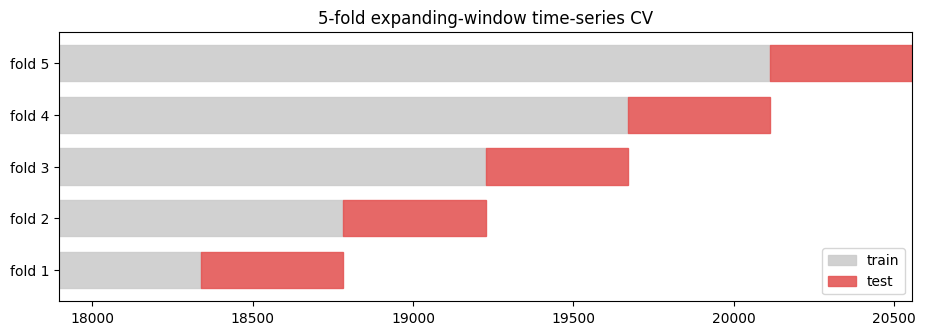

In [4]:
# Reconstruct the CV split boundaries from the saved per-fold metadata in
# the logistic results JSON (any of the three class JSONs has the same split).
with open(SESSION_DIR / 'logistic_results.json') as f:
    log_res = json.load(f)
folds = log_res['l1_balanced']['per_fold']

fold_summary = pd.DataFrame([{
    'fold': fm['fold'],
    'test_start': fm['test_start'],
    'test_end': fm['test_end'],
    'n_test': fm['n_test'],
    'test_spike_rate': fm['test_spike_rate'],
} for fm in folds])
print(fold_summary.to_string(index=False))

# Gantt-style timeline of the expanding windows
fig, ax = plt.subplots(figsize=(11, 3.5))
n = len(folds)
df_dt = df['datetime']
total_start, total_end = df_dt.min(), df_dt.max()
for fm in folds:
    test_s = pd.Timestamp(fm['test_start'])
    test_e = pd.Timestamp(fm['test_end'])
    y = fm['fold']
    # Training (expanding) goes from start up to test_s
    ax.add_patch(Rectangle((total_start, y - 0.35), test_s - total_start, 0.7,
                           color='#cccccc', alpha=0.9, label='train' if y == 1 else None))
    ax.add_patch(Rectangle((test_s, y - 0.35), test_e - test_s, 0.7,
                           color='#e45756', alpha=0.9, label='test' if y == 1 else None))
ax.set_yticks(range(1, n+1))
ax.set_yticklabels([f'fold {i}' for i in range(1, n+1)])
ax.set_xlim(total_start, total_end)
ax.set_ylim(0.4, n + 0.6)
ax.set_title('5-fold expanding-window time-series CV')
ax.legend(loc='lower right')
plt.show()

## 3. Simple model — Logistic regression

`src/train_logistic.py` sweeps **6 variants** in a fully-crossed 3×2 grid:
- regularization ∈ {none (C=1e10), L2 (C=1), L1 (C=1)}
- `class_weight` ∈ {default, balanced}

The cross lets us tell whether regularization *and* class-weight matter independently.

In [5]:
rows = []
for name, res in log_res.items():
    rows.append({
        'variant': name,
        'mean PR-AUC': res['mean_pr_auc'],
        'std': res['std_pr_auc'],
        'concat PR-AUC': res['pr_auc'],
        'ROC-AUC': res['roc_auc'],
        'P@R=0.80': res['precision_at_recall_0.80'],
        'F1': res['f1'],
    })
log_table = pd.DataFrame(rows).sort_values('mean PR-AUC', ascending=False).reset_index(drop=True)
log_table.round(4)

,variant,mean PR-AUC,std,concat PR-AUC,ROC-AUC,P@R=0.80,F1
0,l1_balanced,0.3455,0.1575,0.3712,0.8553,0.1341,0.3809
1,no_regularization_balanced,0.3453,0.1573,0.3717,0.8556,0.1350,0.3810
2,l2_balanced,0.3412,0.1585,0.3672,0.8530,0.1300,0.3809
3,no_regularization,0.2729,0.1889,0.3285,0.8055,0.1238,0.3496
4,l1,0.2705,0.1894,0.3257,0.8019,0.1218,0.3489
5,l2,0.2675,0.1921,0.3269,0.7986,0.1169,0.3473


**Reading the variant table.** The three `*_balanced` variants are statistically tied (within 0.005 mean PR-AUC of each other, against a fold-to-fold std of ~0.16). The three unbalanced variants are also tied with each other but ~0.07 mean PR-AUC behind their balanced counterparts.

The cross design lets us pull out the two marginal effects cleanly:

In [6]:
def m(name): return log_res[name]['mean_pr_auc']

print('Effect of regularization (mean PR-AUC delta, holding class-weight fixed):')
print(f'  no_reg -> L2,  unbalanced: {m("l2") - m("no_regularization"):+.4f}')
print(f'  no_reg -> L1,  unbalanced: {m("l1") - m("no_regularization"):+.4f}')
print(f'  no_reg -> L2,  balanced:   {m("l2_balanced") - m("no_regularization_balanced"):+.4f}')
print(f'  no_reg -> L1,  balanced:   {m("l1_balanced") - m("no_regularization_balanced"):+.4f}')

print("\nEffect of class_weight='balanced' (mean PR-AUC delta, holding regularization fixed):")
print(f'  no_reg:  {m("no_regularization_balanced") - m("no_regularization"):+.4f}')
print(f'  L2:      {m("l2_balanced") - m("l2"):+.4f}')
print(f'  L1:      {m("l1_balanced") - m("l1"):+.4f}')

Effect of regularization (mean PR-AUC delta, holding class-weight fixed):
  no_reg -> L2,  unbalanced: -0.0053
  no_reg -> L1,  unbalanced: -0.0024
  no_reg -> L2,  balanced:   -0.0041
  no_reg -> L1,  balanced:   +0.0002

Effect of class_weight='balanced' (mean PR-AUC delta, holding regularization fixed):
  no_reg:  +0.0724
  L2:      +0.0736
  L1:      +0.0750


**Two clean conclusions:**
1. **Regularization barely matters** at this scale (~63k rows, 16 features, C=1.0). Every reg → reg comparison is within ±0.005.
2. **`class_weight='balanced'` is the dominant lever** and adds +0.072 to +0.075 mean PR-AUC *regardless* of regularization choice. This is the desired pattern — it tells us class-balancing is a property of the loss function, not entangled with regularization.

Tradeoff: balanced variants improve the *ranking* of positives among negatives (what PR-AUC measures) but distort the *absolute probabilities* because the model implicitly assumes a 50/50 prior instead of the true 4/96. For downstream uses that need calibrated probabilities, isotonic / sigmoid calibration on a held-out set recovers calibration without giving up the ranking improvement.

### Coefficients of the saved winner (`l1_balanced`)

In [7]:
stage_a = load(MODELS_DIR / 'logistic_best.pkl')
print(f'variant: {stage_a["variant"]}')
print(f'params:  {stage_a["params"]}\n')

coef_df = (pd.DataFrame({
    'feature': stage_a['features'],
    'coefficient (standardized)': stage_a['model'].coef_[0],
})
.assign(abs_coef=lambda d: d['coefficient (standardized)'].abs())
.sort_values('abs_coef', ascending=False)
.drop(columns='abs_coef')
.reset_index(drop=True))
coef_df.round(3)

variant: l1_balanced
params:  {'penalty': 'l1', 'C': 1.0, 'solver': 'liblinear', 'class_weight': 'balanced'}



,feature,coefficient (standardized)
0,apparent_temperature,11.463
1,temperature_2m,-6.842
2,dewpoint_2m,-4.301
3,wind_speed_10m,3.889
4,wind_speed_100m,-2.824
5,hour,1.015
6,shortwave_radiation,-0.916
7,gas_price_henry_hub,0.879
8,month,-0.536
9,day_of_year,0.377


The very large opposite-sign coefficients on `apparent_temperature` (+11.5) vs `temperature_2m` (−6.8), and on `wind_speed_10m` (+3.9) vs `wind_speed_100m` (−2.8), are a textbook collinearity tell — the model is differencing two near-duplicate inputs to extract a small residual. The interpretable story is still that **heat extremity, gas price, and time-of-day drive linear spike separability**, but the individual signs on the collinear pairs shouldn't be read literally.

## 4. Advanced model — Random Forest

`src/train_random_forest.py` sweeps a 3×3 grid:
- `max_depth` ∈ {10, 20, None}
- `min_samples_leaf` ∈ {1, 5, 20}

Fixed: `n_estimators=300`, `class_weight='balanced_subsample'`, `random_state=42`.

In [8]:
with open(SESSION_DIR / 'rf_results.json') as f:
    rf_res = json.load(f)

rows = []
for name, res in rf_res.items():
    rows.append({
        'variant': name,
        'mean PR-AUC': res['mean_pr_auc'],
        'std': res['std_pr_auc'],
        'concat PR-AUC': res['pr_auc'],
        'ROC-AUC': res['roc_auc'],
        'P@R=0.80': res['precision_at_recall_0.80'],
    })
rf_table = pd.DataFrame(rows).sort_values('mean PR-AUC', ascending=False).reset_index(drop=True)
rf_table.round(4)

,variant,mean PR-AUC,std,concat PR-AUC,ROC-AUC,P@R=0.80
0,depth=None_leaf=20,0.2633,0.1641,0.2724,0.8995,0.2156
1,depth=20_leaf=20,0.2627,0.1639,0.2717,0.8993,0.2150
2,depth=10_leaf=20,0.2596,0.1678,0.2523,0.8947,0.2155
3,depth=20_leaf=5,0.2553,0.1517,0.2584,0.8945,0.2050
4,depth=None_leaf=5,0.2531,0.1501,0.2586,0.8935,0.2021
5,depth=10_leaf=5,0.2486,0.1632,0.2251,0.8859,0.1857
6,depth=10_leaf=1,0.2424,0.1674,0.2120,0.8778,0.1806
7,depth=None_leaf=1,0.2395,0.1362,0.2415,0.8839,0.2004
8,depth=20_leaf=1,0.2328,0.1372,0.2318,0.8866,0.2097


**Winner: `depth=None, leaf=20`.** Trees grown to full depth but with at least 20 samples per leaf — i.e., the forest can split arbitrarily deep where the data supports it, but the leaf-size constraint prevents overfitting on the rare positive class.

### Feature importance

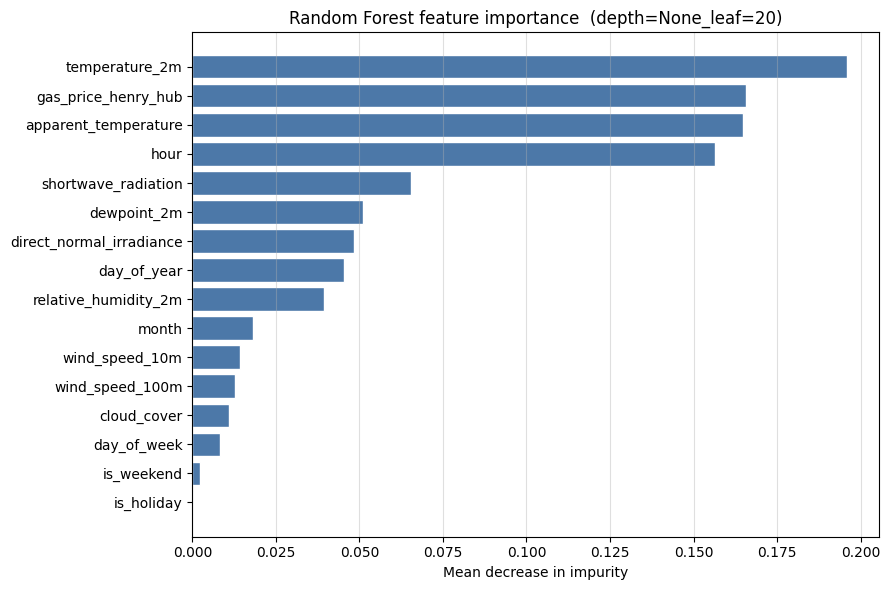

,feature,importance
0,temperature_2m,0.1958
1,gas_price_henry_hub,0.1657
2,apparent_temperature,0.1648
3,hour,0.1566
4,shortwave_radiation,0.0654
5,dewpoint_2m,0.0512
6,direct_normal_irradiance,0.0485
7,day_of_year,0.0453
8,relative_humidity_2m,0.0395
9,month,0.0183


In [9]:
stage_a_rf = load(MODELS_DIR / 'rf_best.pkl')

imp_df = (pd.DataFrame({
    'feature': stage_a_rf['features'],
    'importance': stage_a_rf['model'].feature_importances_,
})
.sort_values('importance', ascending=False)
.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#4c78a8', edgecolor='white')
ax.set_xlabel('Mean decrease in impurity')
ax.set_title(f'Random Forest feature importance  ({stage_a_rf["variant"]})')
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()
imp_df.round(4)

RF emphasizes a different feature mix than logistic. The top contributors — temperature, gas price, hour, apparent temperature — match logistic's top four, but RF puts substantial weight on `day_of_year` and `direct_normal_irradiance` that logistic essentially ignored. RF can use those non-linearly (seasonal regime indicator, conditional radiation effect) where the linear model cannot.

## 5. Sanity check — KNN

`src/train_knn.py` sweeps `k ∈ {5, 25, 75, 200}` with `weights='distance'` so closer neighbors carry more weight (avoids the pathology where all `k` neighbors are negative simply because negatives outnumber positives 20:1).

In [10]:
with open(SESSION_DIR / 'knn_results.json') as f:
    knn_res = json.load(f)

rows = []
for name, res in knn_res.items():
    rows.append({
        'variant': name,
        'mean PR-AUC': res['mean_pr_auc'],
        'std': res['std_pr_auc'],
        'concat PR-AUC': res['pr_auc'],
        'ROC-AUC': res['roc_auc'],
        'mean fit (s)': res['mean_fit_seconds'],
        'mean predict (s)': res['mean_predict_seconds'],
    })
knn_table = pd.DataFrame(rows).sort_values('mean PR-AUC', ascending=False).reset_index(drop=True)
knn_table.round(4)

,variant,mean PR-AUC,std,concat PR-AUC,ROC-AUC,mean fit (s),mean predict (s)
0,k=25,0.2434,0.1318,0.2183,0.7845,0.0017,0.1928
1,k=200,0.2366,0.1379,0.2234,0.8415,0.0018,0.3063
2,k=75,0.2278,0.1263,0.2175,0.8290,0.0017,0.2192
3,k=5,0.1752,0.1117,0.1566,0.6685,0.0020,0.1687


**Winner: `k=25`** at mean PR-AUC 0.243 — well behind logistic (0.346) and RF (0.263). KNN is included as a non-parametric contrast; with a 4% positive class and only 16 features, the local-density estimate is too noisy to compete with parametric / ensemble approaches. Wall-clock time also worsens linearly with `k` because predict-time scales with neighbor count.

## 6. Cross-class comparison

For each model class, take the best variant (by mean per-fold PR-AUC) and overlay them on the same evaluation grid.

In [11]:
# Load the per-class best-variant predictions saved by each training script.
log_pred = np.load(SESSION_DIR / 'logistic_best_predictions.npz')
rf_pred  = np.load(SESSION_DIR / 'rf_best_predictions.npz')
knn_pred = np.load(SESSION_DIR / 'knn_best_predictions.npz')

# Identify each best variant by mean per-fold PR-AUC.
def best_variant(d):
    return max(d, key=lambda k: np.mean([fm['pr_auc'] for fm in d[k]['per_fold']]))

best_log = best_variant(log_res)
best_rf  = best_variant(rf_res)
best_knn = best_variant(knn_res)

best_pred = {
    f'logistic ({best_log})':       (log_pred['y_true'], log_pred['y_proba']),
    f'random_forest ({best_rf})':    (rf_pred['y_true'], rf_pred['y_proba']),
    f'knn ({best_knn})':             (knn_pred['y_true'], knn_pred['y_proba']),
}

summary_rows = []
for label, (y_true, y_proba) in best_pred.items():
    pr_auc = average_precision_score(y_true, y_proba)
    summary_rows.append({'model': label, 'concat PR-AUC': pr_auc})
print(pd.DataFrame(summary_rows).set_index('model').round(4))

                                    concat PR-AUC
model                                            
logistic (l1_balanced)                     0.3712
random_forest (depth=None_leaf=20)         0.2724
knn (k=25)                                 0.2183


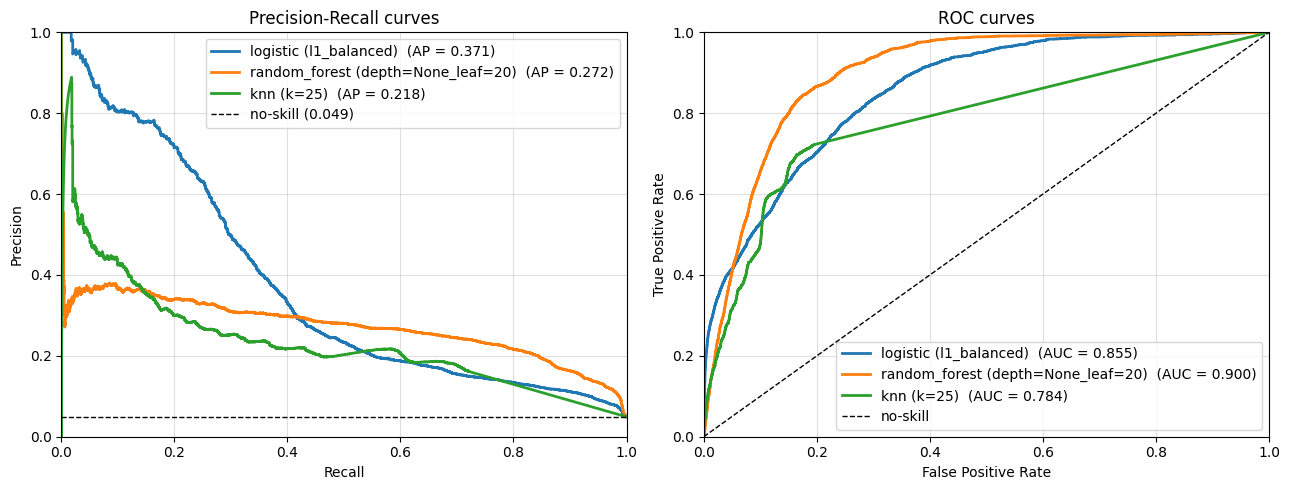

In [12]:
# Precision-Recall overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
baseline = float(np.mean(log_pred['y_true']))
for label, (y_t, y_p) in best_pred.items():
    p, r, _ = precision_recall_curve(y_t, y_p)
    ax.plot(r, p, linewidth=2, label=f'{label}  (AP = {average_precision_score(y_t, y_p):.3f})')
ax.axhline(baseline, color='black', linestyle='--', linewidth=1, label=f'no-skill ({baseline:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Precision-Recall curves')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)

# ROC overlay
ax = axes[1]
for label, (y_t, y_p) in best_pred.items():
    from sklearn.metrics import roc_auc_score
    fpr, tpr, _ = roc_curve(y_t, y_p)
    ax.plot(fpr, tpr, linewidth=2, label=f'{label}  (AUC = {roc_auc_score(y_t, y_p):.3f})')
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label='no-skill')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('ROC curves')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Headline ranking flips between metrics:**
- **PR-AUC**: logistic > RF > KNN
- **ROC-AUC**: RF > logistic > KNN
- **Precision @ Recall=0.80**: RF (0.216) ≈ 2× logistic (0.134) > KNN (0.049)

RF is the operationally better model at fixed recall — it can hit 80% recall at twice the precision of logistic. Logistic wins concat-PR-AUC because it ranks the very rarest events better at the top of the list, but for an operations user picking a working point near recall=0.80, RF wins decisively.

### Per-fold winners — the models disagree across regimes

In [13]:
# Build a per-fold table of PR-AUC by model class.
rows = []
for fold_idx in range(1, 6):
    log_pf = next(fm for fm in log_res[best_log]['per_fold'] if fm['fold'] == fold_idx)
    rf_pf  = next(fm for fm in rf_res[best_rf]['per_fold'] if fm['fold'] == fold_idx)
    knn_pf = next(fm for fm in knn_res[best_knn]['per_fold'] if fm['fold'] == fold_idx)
    rows.append({
        'fold': fold_idx,
        'test_start': log_pf['test_start'][:10],
        'test_end': log_pf['test_end'][:10],
        'spike_rate': log_pf['test_spike_rate'],
        'logistic': log_pf['pr_auc'],
        'random_forest': rf_pf['pr_auc'],
        'knn': knn_pf['pr_auc'],
    })
per_fold = pd.DataFrame(rows)
per_fold['winner'] = per_fold[['logistic', 'random_forest', 'knn']].idxmax(axis=1)
print(per_fold.round(4).to_string(index=False))

print('\nFold-win counts:')
print(per_fold['winner'].value_counts())

 fold test_start   test_end  spike_rate  logistic  random_forest    knn        winner
    1 2020-03-19 2021-06-05      0.0274    0.3704         0.1981 0.1090      logistic
    2 2021-06-05 2022-08-22      0.1053    0.5880         0.3342 0.2319      logistic
    3 2022-08-22 2023-11-08      0.0761    0.3339         0.5499 0.4134 random_forest
    4 2023-11-08 2025-01-23      0.0174    0.0916         0.1022 0.0909 random_forest
    5 2025-01-24 2026-04-11      0.0200    0.3436         0.1318 0.3718           knn

Fold-win counts:
winner
logistic         2
random_forest    2
knn              1
Name: count, dtype: int64


A **2-2-1 split** across model classes:
- **Folds 1-2** (high-volatility 2020-22 window): **logistic** wins.
- **Folds 3-4** (transitional 2022-25 window): **RF** wins.
- **Fold 5** (low-volatility 2025-26): **KNN** wins.

Cross-fold std (~0.16 for the logistic leader) is *larger* than the 0.08 mean-PR-AUC gap between logistic and RF — the headline ordering is well within fold-to-fold noise. An **ensemble or regime-aware switch** is a natural follow-up, but we deferred that since the current numbers are already informative enough to motivate the recency analysis below.

## 7. Recency analysis — does training-window choice matter?

`src/recency_analysis.py` holds out the most recent 12 months (2025-04-12 → 2026-04-11, n=8,760, spike rate 2.10%) as a fixed test set, then refits the best RF on three training windows ending at the test boundary: all history, the last 3 years, and the last 1 year.

     window  n_train train_start  train_spike_rate  PR-AUC  ROC-AUC  Precision  Recall
all_history    55031  2019-01-01            0.0484  0.1292   0.9165     0.1705  0.4457
    3_years    26304  2022-04-12            0.0727  0.1190   0.9080     0.1417  0.4783
     1_year     8760  2024-04-12            0.0170  0.1796   0.8967     0.2347  0.3533


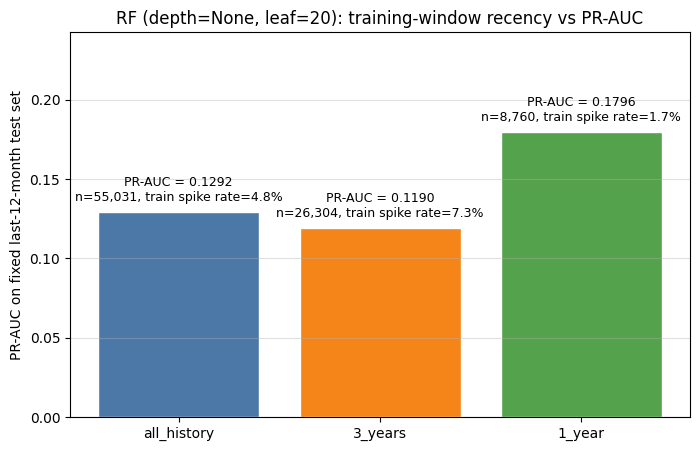

In [14]:
with open(SESSION_DIR / 'recency_results.json') as f:
    rec_res = json.load(f)

rec_rows = []
for name in ['all_history', '3_years', '1_year']:
    r = rec_res['windows'][name]
    rec_rows.append({
        'window': name,
        'n_train': r['n_train'],
        'train_start': r['train_start'][:10],
        'train_spike_rate': r['train_spike_rate'],
        'PR-AUC': r['pr_auc'],
        'ROC-AUC': r['roc_auc'],
        'Precision': r['precision'],
        'Recall': r['recall'],
    })
rec_table = pd.DataFrame(rec_rows)
print(rec_table.round(4).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
names = rec_table['window'].tolist()
pr = rec_table['PR-AUC'].tolist()
n_train = rec_table['n_train'].tolist()
spike = rec_table['train_spike_rate'].tolist()
bars = ax.bar(names, pr, color=['#4c78a8', '#f58518', '#54a24b'], edgecolor='white')
for bar, n, s in zip(bars, n_train, spike):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'PR-AUC = {bar.get_height():.4f}\nn={n:,}, train spike rate={s*100:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('PR-AUC on fixed last-12-month test set')
ax.set_title('RF (depth=None, leaf=20): training-window recency vs PR-AUC')
ax.set_ylim(0, max(pr) * 1.35)
ax.grid(True, axis='y', alpha=0.4)
plt.show()

## 8. Uri sensitivity

After the original Session-7 writeup we returned to the open question flagged in `7_reflection.md`: **does Winter Storm Uri (Feb 2021) inflate our headline numbers?** Two analyses close that loop. Source scripts:

- `src/uri_sensitivity.py` — window-exclusion ablation (refit each best-of-class model with and without the Uri window)
- `src/uri_per_fold_decomposition.py` — split each fold's saved predictions into Uri vs non-Uri components

Artifacts under `outputs/uri_sensitivity/`. The Uri window is defined as **2021-02-10 → 2021-02-21** (288 hourly rows; 192 are spikes — 6.7% of all spike-labeled hours in the dataset, with a 100% spike rate during the Feb 14-19 storm peak).

In [15]:
URI_RESULTS = SESSION_DIR.parent / 'uri_sensitivity'
with open(URI_RESULTS / 'ablation_results.json') as f:
    uri_ablation = json.load(f)

rows = []
for label, blocks in uri_ablation['stage1'].items():
    with_r = blocks['with_uri']; without_r = blocks['without_uri']
    rows.append({
        'model': label,
        'mean PR-AUC (with Uri)':     with_r['mean_pr_auc'],
        'std (with Uri)':             with_r['std_pr_auc'],
        'mean PR-AUC (without Uri)':  without_r['mean_pr_auc'],
        'std (without Uri)':          without_r['std_pr_auc'],
        'Δ (without − with)':         without_r['mean_pr_auc'] - with_r['mean_pr_auc'],
    })
ablation_table = pd.DataFrame(rows).set_index('model')
ablation_table.round(4)

,mean PR-AUC (with Uri),std (with Uri),mean PR-AUC (without Uri),std (without Uri),Δ (without − with)
model,,,,,
logistic (l1_balanced),0.3455,0.1575,0.3010,0.2285,-0.0445
random_forest (depth=None_leaf=20),0.2633,0.1641,0.2873,0.1931,0.0240
knn (k=25),0.2434,0.1318,0.1386,0.1325,-0.1048


**Three model classes, three different Uri responses:**

- **Logistic loses 0.045 PR-AUC** without Uri. The Uri pattern (extreme low temperature + high gas) is linearly separable — it's a textbook case the linear model can pick off cleanly.
- **RF *improves* by 0.024 PR-AUC** without Uri. The forest doesn't need Uri's extreme cluster — and Uri pulled splits toward an outlier regime that doesn't generalize.
- **KNN loses 0.105 PR-AUC** — its local-density estimate collapses without Uri's dense positive-class cluster.

Note also that the without-Uri runs have *larger* fold-to-fold std for every model. Uri was a stabilizing force on the headline number; remove it and the averages get more sensitive to which years are in test.

### Per-fold decomposition

Now the more striking view: split fold 1's PR-AUC into Uri-window test rows vs everything else. Uri's test-set exposure is entirely in fold 1 (Mar 2020 → Jun 2021 test window). Folds 2-5 contain no Uri rows.

In [16]:
with open(URI_RESULTS / 'per_fold_decomposition.json') as f:
    uri_decomp = json.load(f)

rows = []
for cls, blocks in uri_decomp['models'].items():
    for fm in blocks['per_fold']:
        rows.append({
            'model': cls,
            'fold': fm['fold'],
            'n_test': fm['n_test'],
            'n_uri': fm['n_uri'],
            'PR-AUC (all)':     fm['pr_auc_all'],
            'PR-AUC (Uri)':     fm['pr_auc_uri'],
            'PR-AUC (non-Uri)': fm['pr_auc_non_uri'],
        })
decomp_table = pd.DataFrame(rows)
# Focus on fold 1 (the only fold with Uri test rows)
print('Fold 1 only (the only fold with Uri test rows):')
print(decomp_table[decomp_table['fold'] == 1].set_index('model').round(4).to_string())
print('\nFolds 2-5 PR-AUC (all) for comparison — Uri columns are NaN by construction:')
print(decomp_table[decomp_table['fold'] != 1].pivot(index='fold', columns='model', values='PR-AUC (all)').round(4).to_string())

Fold 1 only (the only fold with Uri test rows):
               fold  n_test  n_uri  PR-AUC (all)  PR-AUC (Uri)  PR-AUC (non-Uri)
model                                                                           
logistic          1   10631    288        0.3704        0.9610            0.0670
random_forest     1   10631    288        0.1981        0.9775            0.1695
knn               1   10631    288        0.1090        0.8287            0.0683

Folds 2-5 PR-AUC (all) for comparison — Uri columns are NaN by construction:
model     knn  logistic  random_forest
fold                                  
2      0.2319    0.5880         0.3342
3      0.4134    0.3339         0.5499
4      0.0909    0.0916         0.1022
5      0.3718    0.3436         0.1318


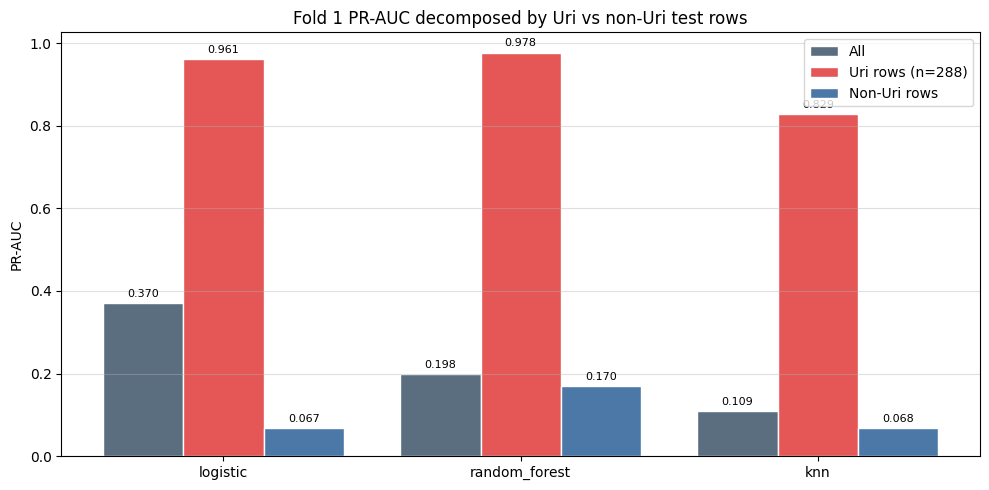

In [17]:
# Visualize fold 1's decomposition
fold1 = decomp_table[decomp_table['fold'] == 1].copy()
classes = fold1['model'].tolist()
x = np.arange(len(classes))
width = 0.27
fig, ax = plt.subplots(figsize=(10, 5))
all_vals = fold1['PR-AUC (all)'].to_numpy()
uri_vals = fold1['PR-AUC (Uri)'].to_numpy()
non_uri_vals = fold1['PR-AUC (non-Uri)'].to_numpy()
ax.bar(x - width, all_vals,     width, label='All',                          color='#5b6e7f', edgecolor='white')
ax.bar(x,         uri_vals,     width, label=f'Uri rows (n={int(fold1["n_uri"].iloc[0])})', color='#e45756', edgecolor='white')
ax.bar(x + width, non_uri_vals, width, label='Non-Uri rows',                 color='#4c78a8', edgecolor='white')
for xi, (a, u, n) in enumerate(zip(all_vals, uri_vals, non_uri_vals)):
    ax.text(xi - width, a + 0.01, f'{a:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(xi,         u + 0.01, f'{u:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(xi + width, n + 0.01, f'{n:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('PR-AUC')
ax.set_title('Fold 1 PR-AUC decomposed by Uri vs non-Uri test rows')
ax.legend(); ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

**This is the bombshell.** Fold 1's headline PR-AUC for every model class is **dominated by Uri detection**:

- On the **288 Uri rows**, every model is at near-ceiling performance — PR-AUC of 0.96 (logistic), 0.98 (RF), 0.83 (KNN). Uri is essentially a string of guaranteed spikes sitting in unusual feature space.
- On the **other 10,343 fold-1 test rows**, the same models score **0.07-0.17** — barely better than random for a 2.7% positive-class baseline.

Implication: the fold-1 column we've been quoting in every comparison table answers **"can your model detect Winter Storm Uri?"** (yes — any model can). The harder question — "can your model detect a normal Texas spike?" — is much less well-answered than the headline implies.

### What this changes for the final submission

- **Headline numbers in §3 are partly Uri-driven.** The 0.346 logistic mean PR-AUC includes a fold-1 score of 0.370 that is really 0.067 on non-Uri test rows. The ranking (logistic > RF > KNN) survives, but the magnitudes are inflated by an easy ~6.7% Uri slice.
- **The recency analysis had Uri sensitivity baked in already.** The 1-year and 3-year training windows already exclude Uri (Uri is more than 3 years before the 2025-04 test boundary). This ablation makes that effect explicit.
- **For the final writeup, report both with-Uri and without-Uri numbers** as a robustness check on a single extreme event — that's the honest framing.

See `multihub_findings.md` for the Stage-2 (magnitude) Uri sensitivity, which is the more dramatic story (without Uri, R² goes from −0.42 to −0.05 and median dollar error drops 27%).

**Recent-only training helped substantially.** The 1-year model beat all-history by **+0.05 PR-AUC** (0.180 vs 0.129).

The 3-year window is the *worst* of the three because it overweights the 2022-23 high-volatility regime — a 7.3% train spike rate against a 2.1% test spike rate is a regime mismatch. The 1-year window's 1.7% spike rate matches the test distribution much more closely.

This is consistent with the **structural-change** narrative: post-Uri ERCOT volatility has subsided, more transmission and renewables are online, and hourly spike dynamics in 2024-26 do not look like 2021-22. ROC-AUC barely moves across windows (~0.90 → 0.90 → 0.90) — the ranking ability is preserved, what changes is the precision-vs-recall tradeoff.

## 9. Open questions carried into the final checkpoint

1. **Spike *magnitude* prediction (regression).** Stage 2 in the final pipeline regresses `log(SPP) | SPP > $100`. See `notebooks/08_combined_evaluation.ipynb` and `multihub_findings.md` for the stage-2 results.

2. **Reconciling the strongest-predictors view.** Logistic and RF agree on the *headline four* (temperature, apparent temperature, gas price, hour) but disagree on the rest. The logistic-coefficient signs on collinear pairs are not reliably interpretable; RF's impurity-importance ranking is more robust but doesn't tell us sign or magnitude.

3. **Are there multiple "types" of spikes?** The fold-by-fold disagreements and the recency finding both point to structurally different spike regimes (heat-volatility, post-storm scarcity, gas-driven). Splitting into regimes would add complexity but might resolve the model-class disagreement.

4. **Calibration follow-up.** `class_weight='balanced'` improves ranking at the cost of calibrated probabilities. `CalibratedClassifierCV` on a held-out fold would recover calibration without giving up the ranking gain — required if downstream uses need meaningful absolute probabilities rather than just an ordering.

5. **Multi-hub generalization.** All work here is HB_HOUSTON only. `multihub_findings.md` documents the pooled-HB_* re-run; the conclusion was that pooling adds rows but not independent observations, and the headline numbers were within fold-to-fold variance of the Houston-only results.